# YOLO11 — 에어 피팅 종류 검출 - Colab 용

[AI Hub 에어 피팅 조립 상태 데이터](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71927) 샘플을 이용해  
**Ultralytics YOLO11**로 중간 조립모듈 내 에어피팅 **종류(유형)** 를 검출하는 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `Air_Fitting_Type_Detection.zip` (조립모듈 200장) |
| 클래스 | `Annotation_part_type` (예: KRPUC형, KRPPL형) |
| 모델 | **YOLO11s** (`yolo11s.pt`) — AI Hub 권장 모델 |
| 선행 EDA | `14_Air_Fitting_EDA.ipynb` |

## 0. 환경 설정

In [1]:
%pip install -U ultralytics

import json
import shutil
import zipfile
from pathlib import Path

import torch
import yaml
from IPython.display import Image as IPImage, display
from ultralytics import YOLO, __version__

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"

ROOT = Path("/content") if IN_COLAB else Path.cwd()
if not (ROOT / "Air_Fitting_Type_Detection.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "Air_Fitting_Type_Detection.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "Air_Fitting_Type_Detection.zip"
DATA_ROOT = ROOT / "air_fitting"
YOLO_DIR = ROOT / "air_fitting_yolo"
YAML_PATH = YOLO_DIR / "air_fitting.yaml"

RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"
MODULE_KEY = "중간조립모듈"

MODEL_NAME = "yolo11s.pt"
CONF_THRESH = 0.25
EXPERIMENT = "yolo11_air_fitting"

print(f"환경       : {'Colab' if IN_COLAB else '로컬'}")
print(f"Ultralytics: {__version__}")
print(f"Device     : {DEVICE}")
print(f"ROOT       : {ROOT.resolve()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
환경       : Colab
Ultralytics: 8.4.68
Device     : 0
ROOT       : /content


## 1. 데이터 준비 (압축 해제 + YOLO 변환)

In [2]:
VAL_ANGLES = {"45°"}  # 카메라 45° 이미지를 검증셋으로 사용


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    jpgs = [p for p in root.rglob("*.jpg") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(jpgs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            # 한글 깨짐 방지 로직 수정: cp437 인코딩이 불가능한 경우(이미 유니코드인 경우) 그대로 사용
            try:
                if not (info.flag_bits & 0x800):
                    name = info.filename.encode("cp437").decode("cp949")
                else:
                    name = info.filename
            except (UnicodeEncodeError, UnicodeDecodeError):
                name = info.filename

            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_subdir(parent: Path, keyword: str) -> Path:
    for p in parent.iterdir():
        if p.is_dir() and keyword in p.name:
            return p
    raise FileNotFoundError(f"'{keyword}' 하위 폴더를 찾을 수 없습니다: {parent}")


def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    bw, bh = x2 - x1, y2 - y1
    return (x1 + x2) / 2 / img_w, (y1 + y2) / 2 / img_h, bw / img_w, bh / img_h


def collect_class_names(label_module: Path) -> list[str]:
    names = set()
    for jp in label_module.glob("*.json"):
        data = json.loads(jp.read_text(encoding="utf-8-sig"))
        for ann in data.get("Annotation", []):
            names.add(ann["Annotation_part_type"])
    return sorted(names)


def prepare_yolo_dataset(data_root: Path, output_dir: Path) -> dict:
    label_root = data_root / LABEL_DIR_NAME
    raw_root = data_root / RAW_DIR_NAME
    label_module = find_subdir(label_root, MODULE_KEY)
    raw_module = find_subdir(raw_root, MODULE_KEY)

    class_names = collect_class_names(label_module)
    class_to_id = {n: i for i, n in enumerate(class_names)}

    for split in ("train", "val"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    stats = {"train": 0, "val": 0, "skipped": 0, "instances": 0}
    for json_path in sorted(label_module.glob("*.json")):
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        meta = data["images"]
        anns = data.get("Annotation", [])
        if not anns:
            stats["skipped"] += 1
            continue

        src_img = raw_module / meta["file_name"]
        if not src_img.exists():
            stats["skipped"] += 1
            continue

        split = "val" if meta.get("Photo_angle") in VAL_ANGLES else "train"
        stem = Path(meta["file_name"]).stem
        dst_img = output_dir / "images" / split / meta["file_name"]
        dst_lbl = output_dir / "labels" / split / f"{stem}.txt"
        shutil.copy2(src_img, dst_img)

        w, h = meta["Img_resolution"]
        lines = []
        for ann in anns:
            x1, y1, x2, y2 = ann["Annotation_bbox"]
            cls_id = class_to_id[ann["Annotation_part_type"]]
            xc, yc, nw, nh = xyxy_to_yolo(x1, y1, x2, y2, w, h)
            lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            stats["instances"] += 1
        dst_lbl.write_text("\n".join(lines) + "\n", encoding="utf-8")
        stats[split] += 1

    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(class_names)}\n"
        f"names:\n" + "".join(f"  - {n}\n" for n in class_names),
        encoding="utf-8",
    )
    stats["yaml"] = str(YAML_PATH)
    stats["classes"] = class_names
    return stats


need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

for cache in YOLO_DIR.rglob("*.cache"):
    cache.unlink(missing_ok=True)

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
print("YOLO 데이터셋:", {k: v for k, v in stats.items() if k != "classes"})
print("클래스:", stats["classes"])
print(f"train 이미지: {len(list((YOLO_DIR / 'images/train').glob('*.jpg')))}")
print(f"val   이미지: {len(list((YOLO_DIR / 'images/val').glob('*.jpg')))}")

YOLO 데이터셋: {'train': 116, 'val': 84, 'skipped': 0, 'instances': 719, 'yaml': '/content/air_fitting_yolo/air_fitting.yaml'}
클래스: ['KRPPL형', 'KRPUC형']
train 이미지: 116
val   이미지: 84


## 2. YOLO11 모델 학습

In [3]:
# RTX 3060 : 약 10분 소요
# Colab : 약 4분 소요
EPOCHS = 100
BATCH = 8
IMGSZ = 640

model = YOLO(MODEL_NAME)
results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    name=EXPERIMENT,
    exist_ok=True,
    patience=30,
    plots=True,
    verbose=True,
)

BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
print(f"최적 가중치: {BEST_WEIGHTS.resolve()}")

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/air_fitting_yolo/air_fitting.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_air_fitting, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

## 3. 검증 (Validation)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3050.9±1469.9 MB/s, size: 163.4 KB)
val: Scanning /content/air_fitting_yolo/labels/val.cache... 84 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 84/84 32.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.9it/s 2.1s
                   all         84        310      0.898       0.99      0.967       0.84
                KRPPL형         84        181      0.881       0.98      0.964      0.826
                KRPUC형         84        129      0.915      0.999      0.969      0.855
Speed: 1.8ms preprocess, 4.9ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val
mAP50    : 0.9665
mAP50-95 : 0.8404

image 1/1 /content/air_fitting_yolo/images/va

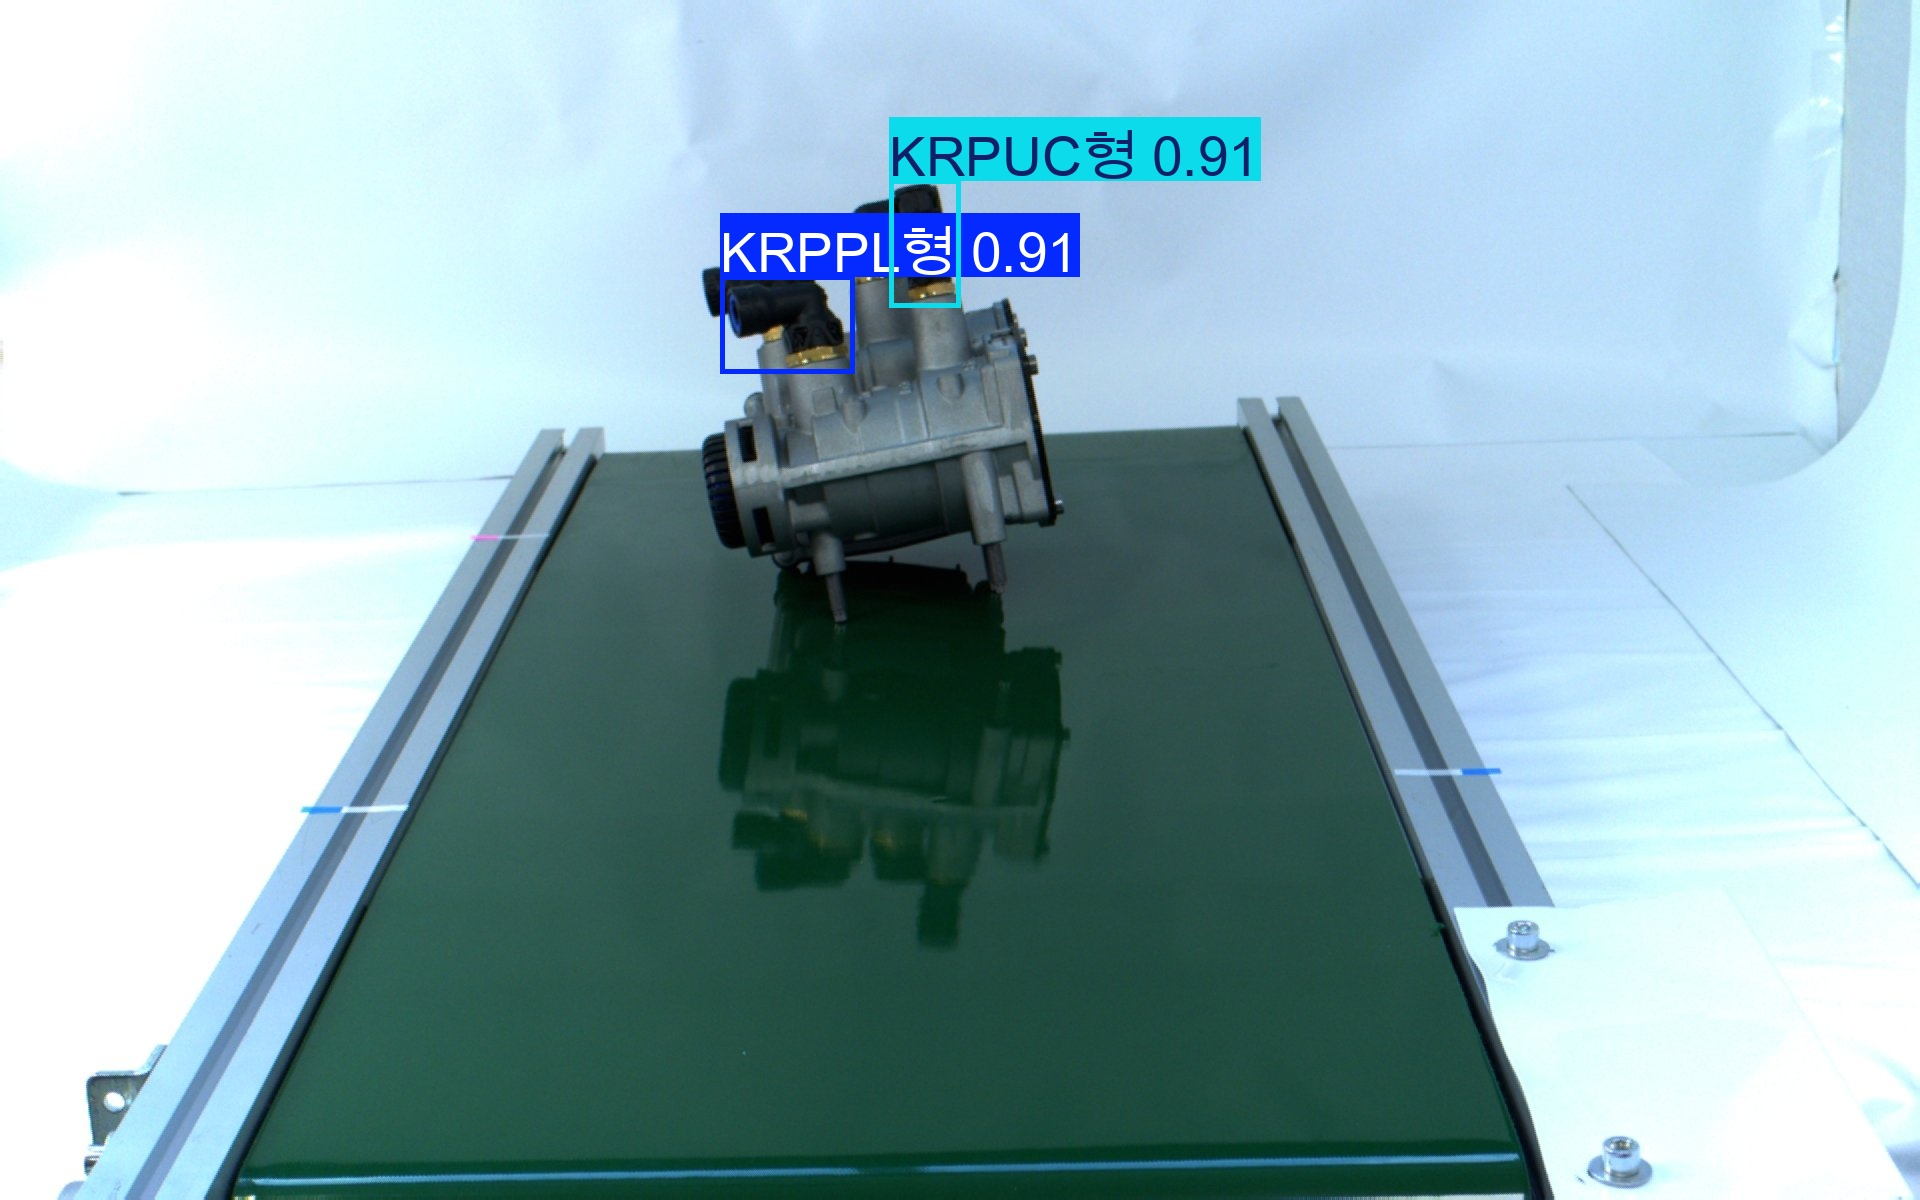

저장: /content/runs/detect/yolo11_air_fitting_val_probe


In [4]:
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data=str(YAML_PATH), imgsz=IMGSZ, device=DEVICE, conf=CONF_THRESH)
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")

# 검증 이미지 1장 추론 미리보기
val_images = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))
if val_images:
    probe = best_model.predict(source=str(val_images[0]), conf=CONF_THRESH, save=True, name=f"{EXPERIMENT}_val_probe")
    out_dir = Path(probe[0].save_dir)
    pred_img = next(out_dir.glob("*.jpg"))
    display(IPImage(filename=str(pred_img), width=700))
    print(f"저장: {out_dir}")

## 4. 이미지 추론 (Predict)


image 1/1 /content/air_fitting_yolo/images/train/Module_001_A_CV_00_0001.jpg: 416x640 1 KRPPL형, 1 KRPUC형, 11.0ms
Speed: 2.8ms preprocess, 11.0ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/yolo11_air_fitting_predict

[train] Module_001_A_CV_00_0001.jpg
  - KRPUC형: conf=0.925
  - KRPPL형: conf=0.921


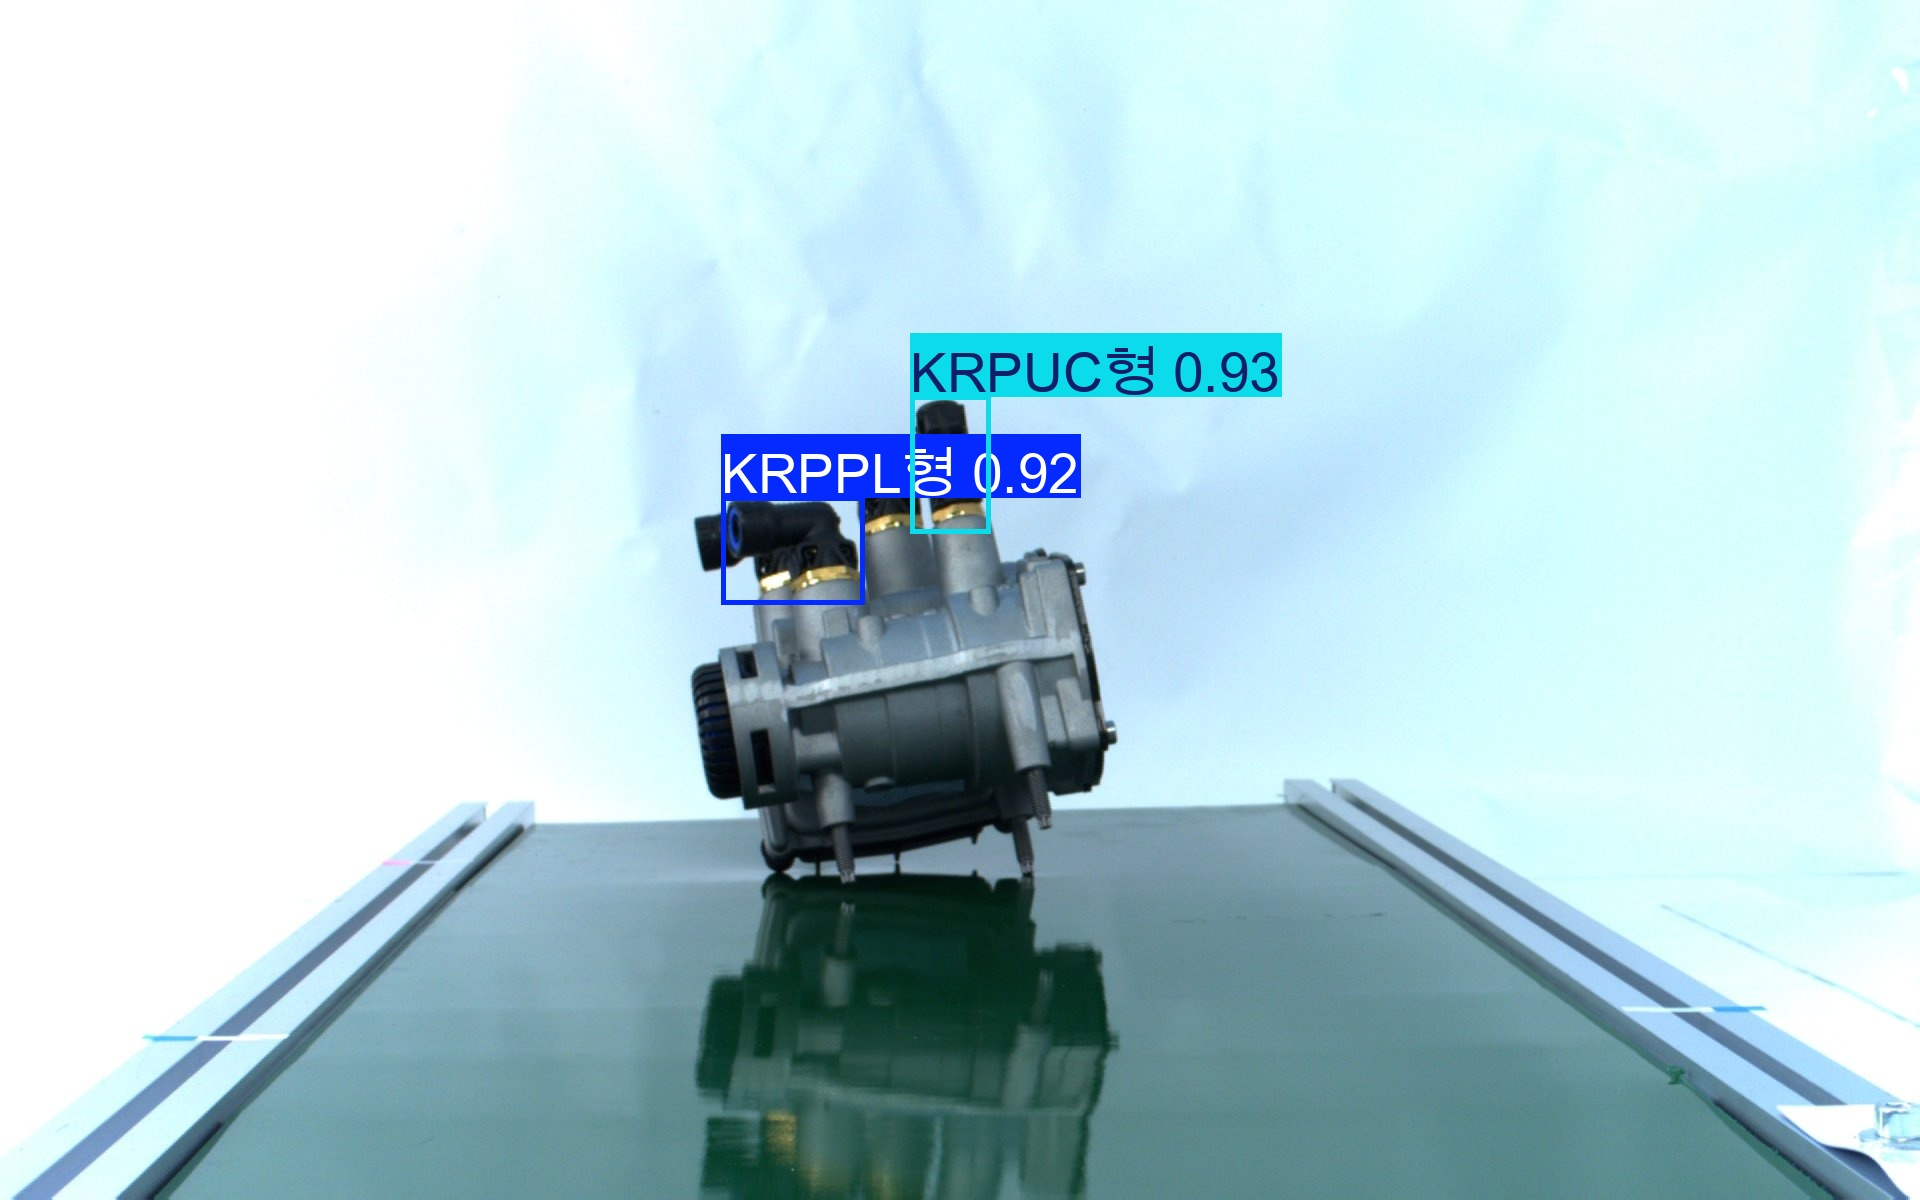


image 1/1 /content/air_fitting_yolo/images/train/Module_001_A_CV_00_0002.jpg: 416x640 1 KRPPL형, 1 KRPUC형, 10.1ms
Speed: 2.4ms preprocess, 10.1ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/yolo11_air_fitting_predict-2

[train] Module_001_A_CV_00_0002.jpg
  - KRPUC형: conf=0.932
  - KRPPL형: conf=0.913


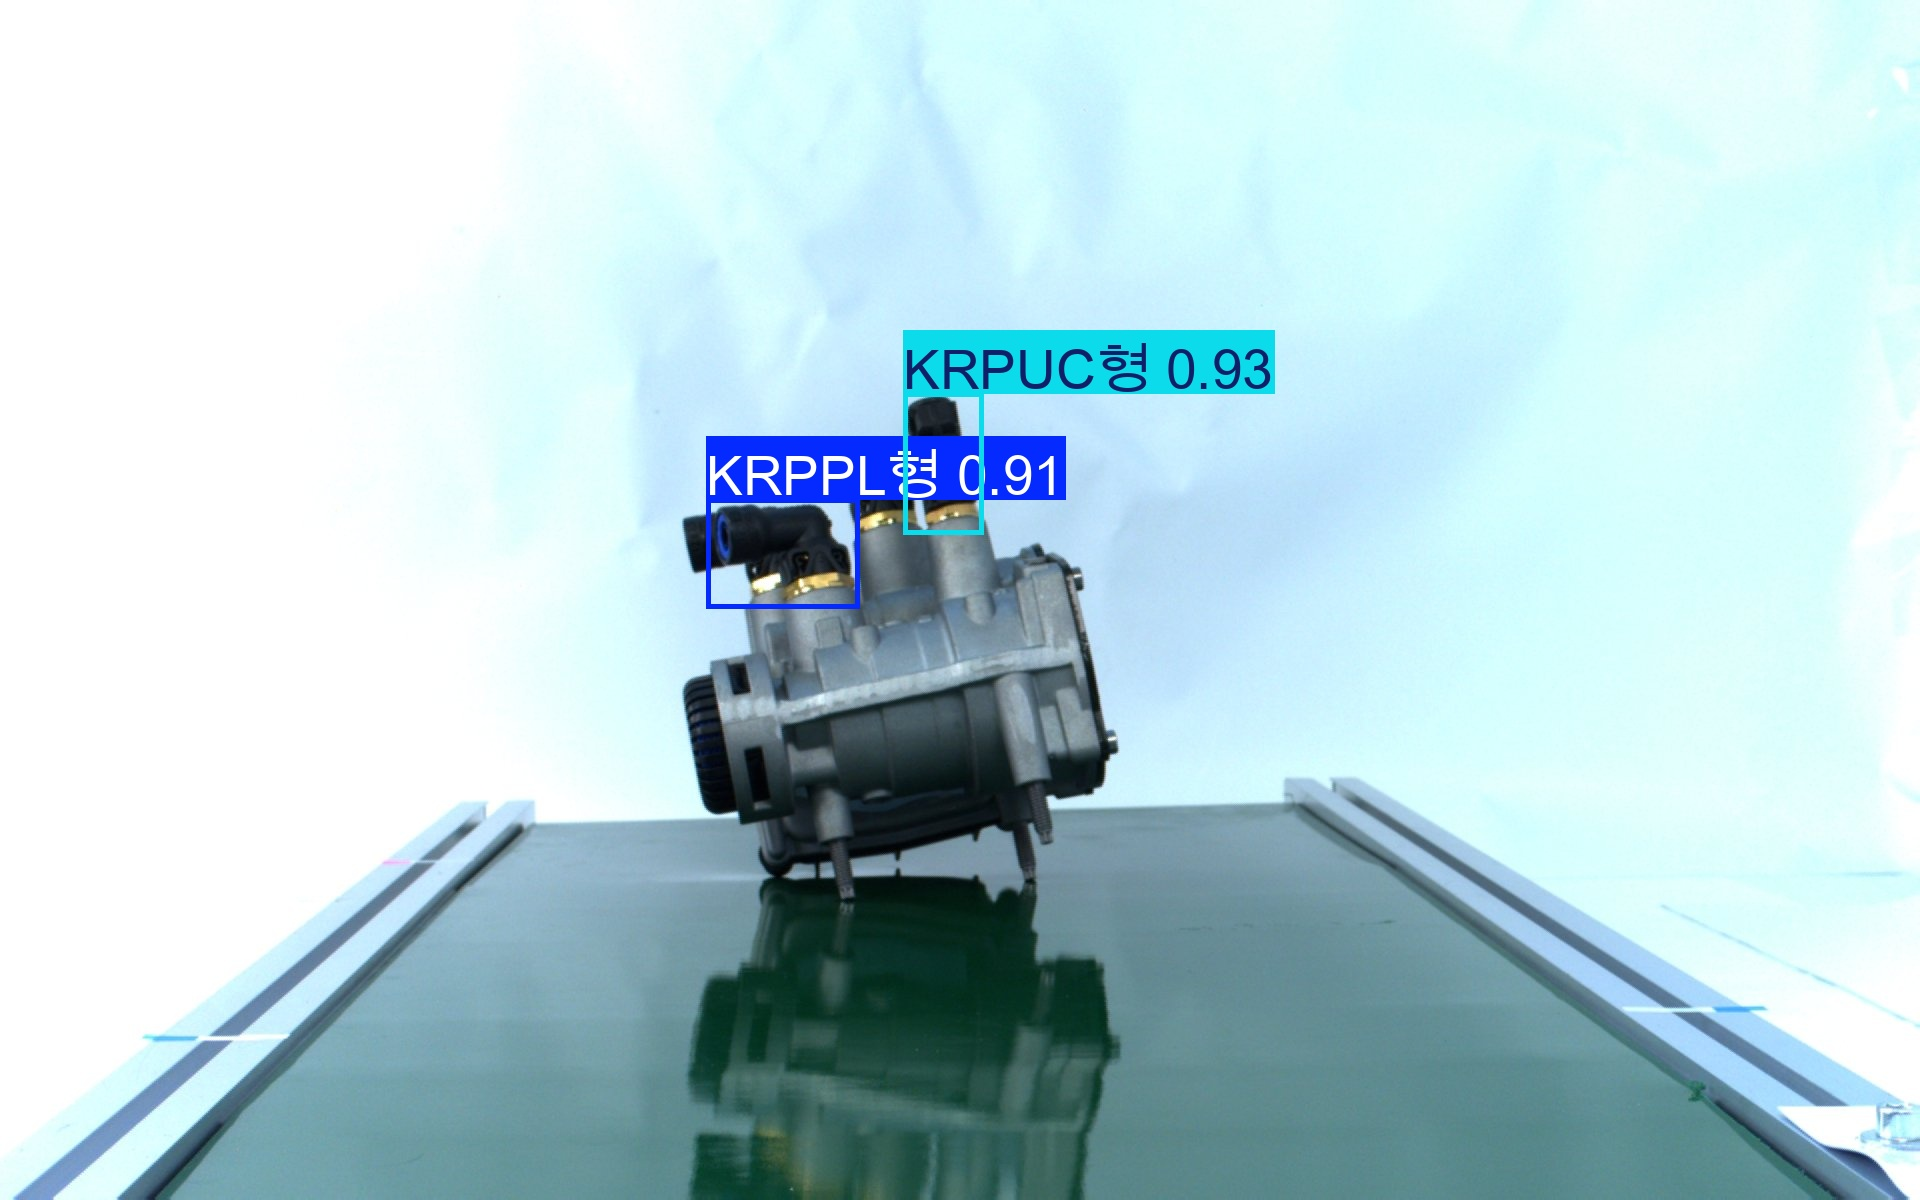


image 1/1 /content/air_fitting_yolo/images/train/Module_001_A_CV_00_0003.jpg: 416x640 1 KRPPL형, 1 KRPUC형, 10.1ms
Speed: 2.3ms preprocess, 10.1ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/yolo11_air_fitting_predict-3

[train] Module_001_A_CV_00_0003.jpg
  - KRPUC형: conf=0.930
  - KRPPL형: conf=0.919


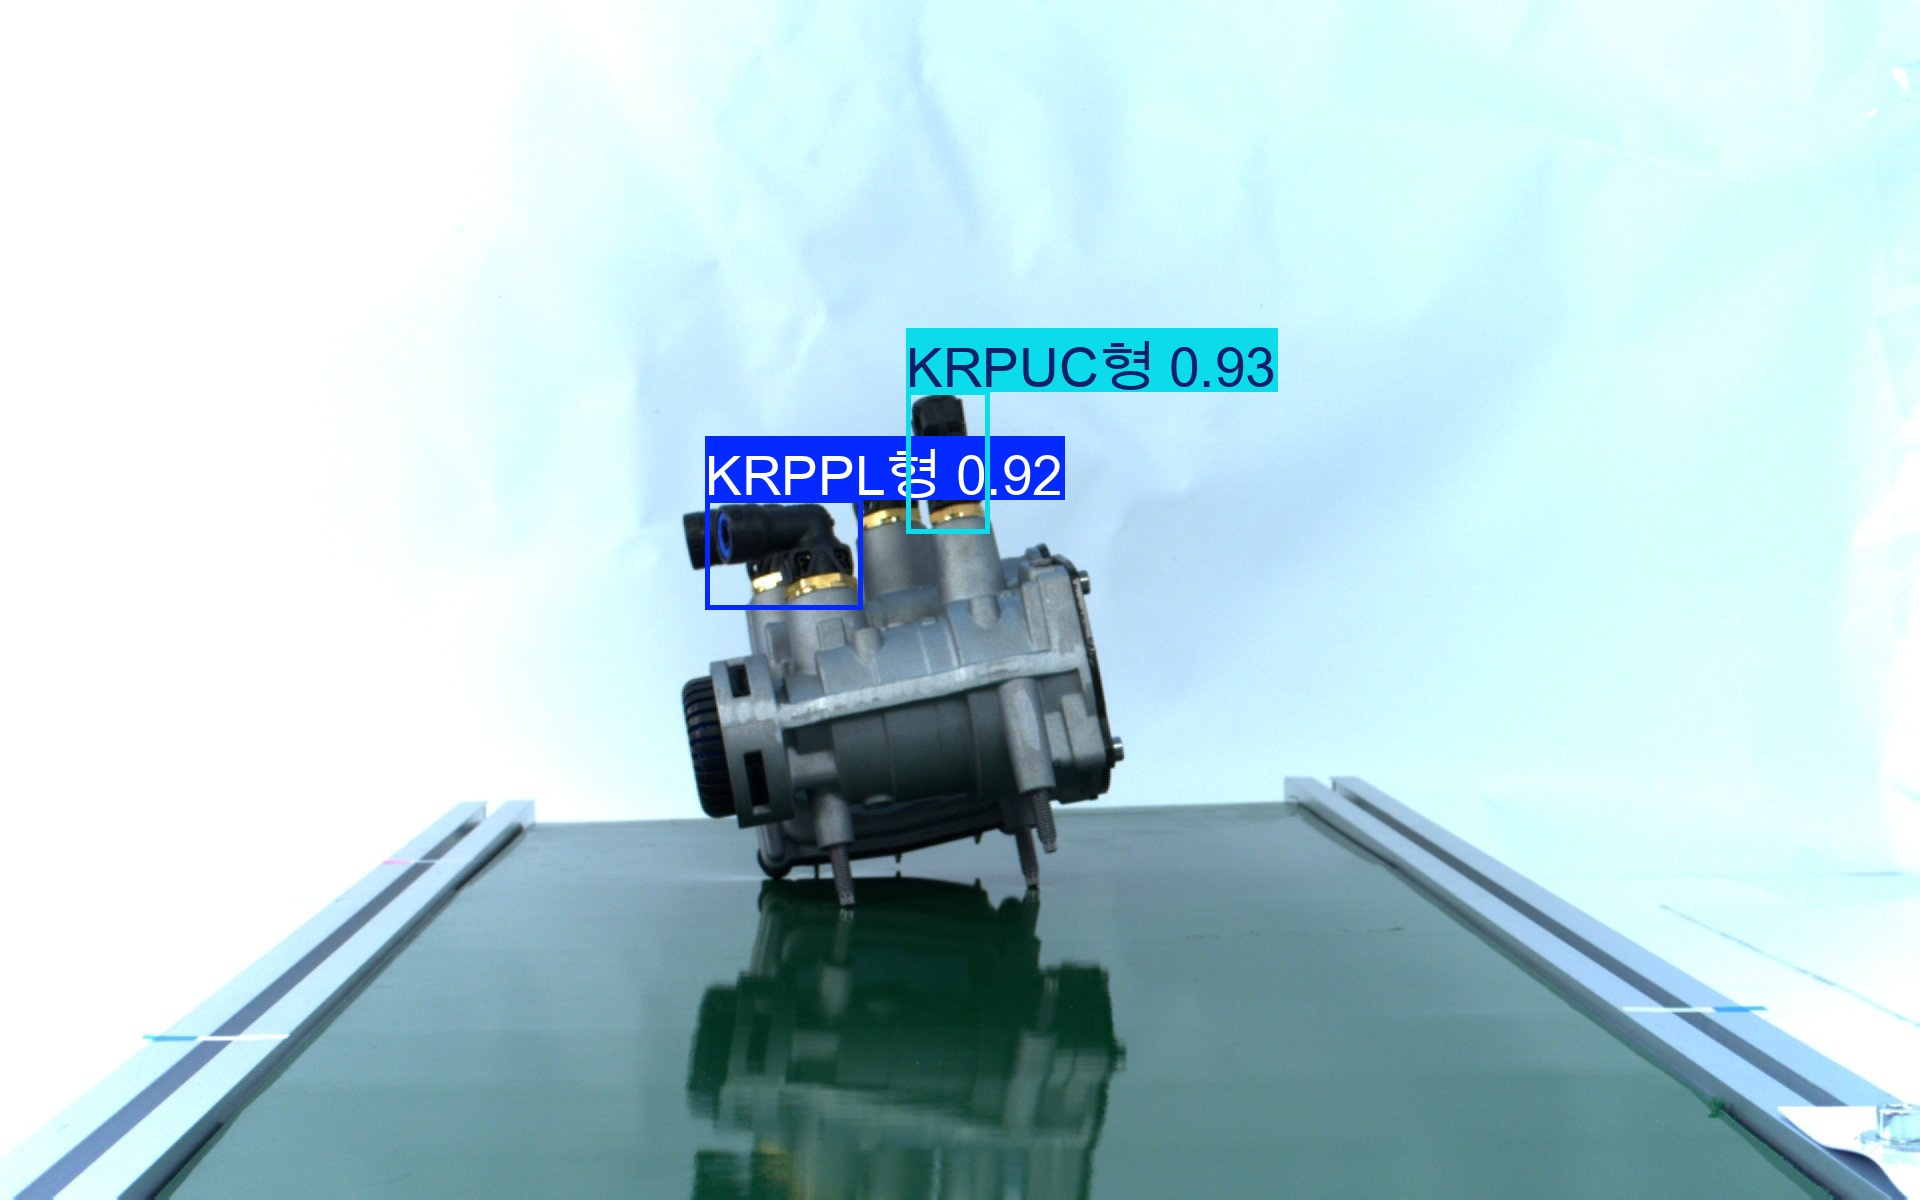


image 1/1 /content/air_fitting_yolo/images/val/Module_001_A_CV_45_0029.jpg: 416x640 1 KRPPL형, 1 KRPUC형, 10.1ms
Speed: 2.3ms preprocess, 10.1ms inference, 1.7ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/yolo11_air_fitting_predict-4

[val] Module_001_A_CV_45_0029.jpg
  - KRPUC형: conf=0.906
  - KRPPL형: conf=0.905


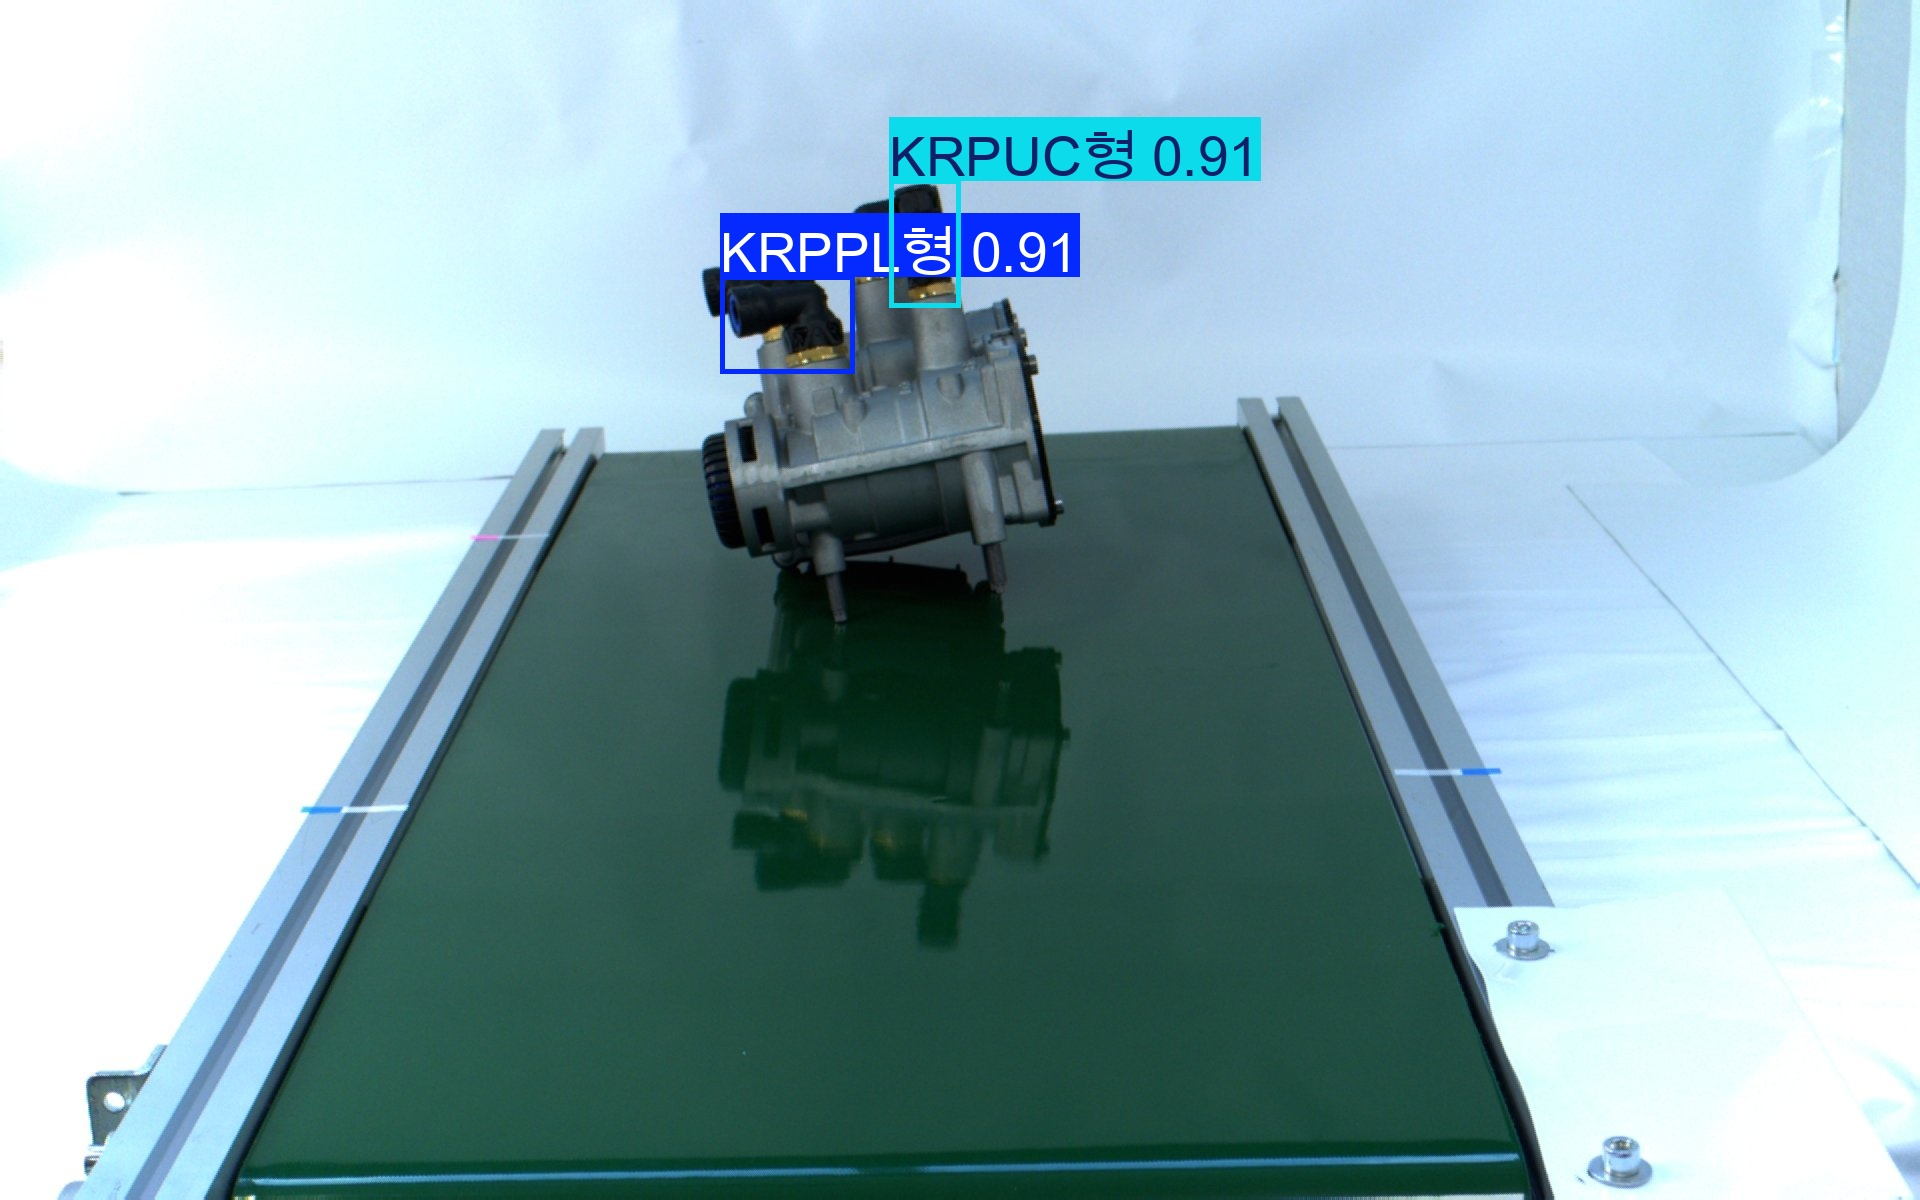


image 1/1 /content/air_fitting_yolo/images/val/Module_001_A_CV_45_0030.jpg: 416x640 1 KRPPL형, 1 KRPUC형, 10.2ms
Speed: 2.3ms preprocess, 10.2ms inference, 1.5ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/yolo11_air_fitting_predict-5

[val] Module_001_A_CV_45_0030.jpg
  - KRPPL형: conf=0.921
  - KRPUC형: conf=0.904


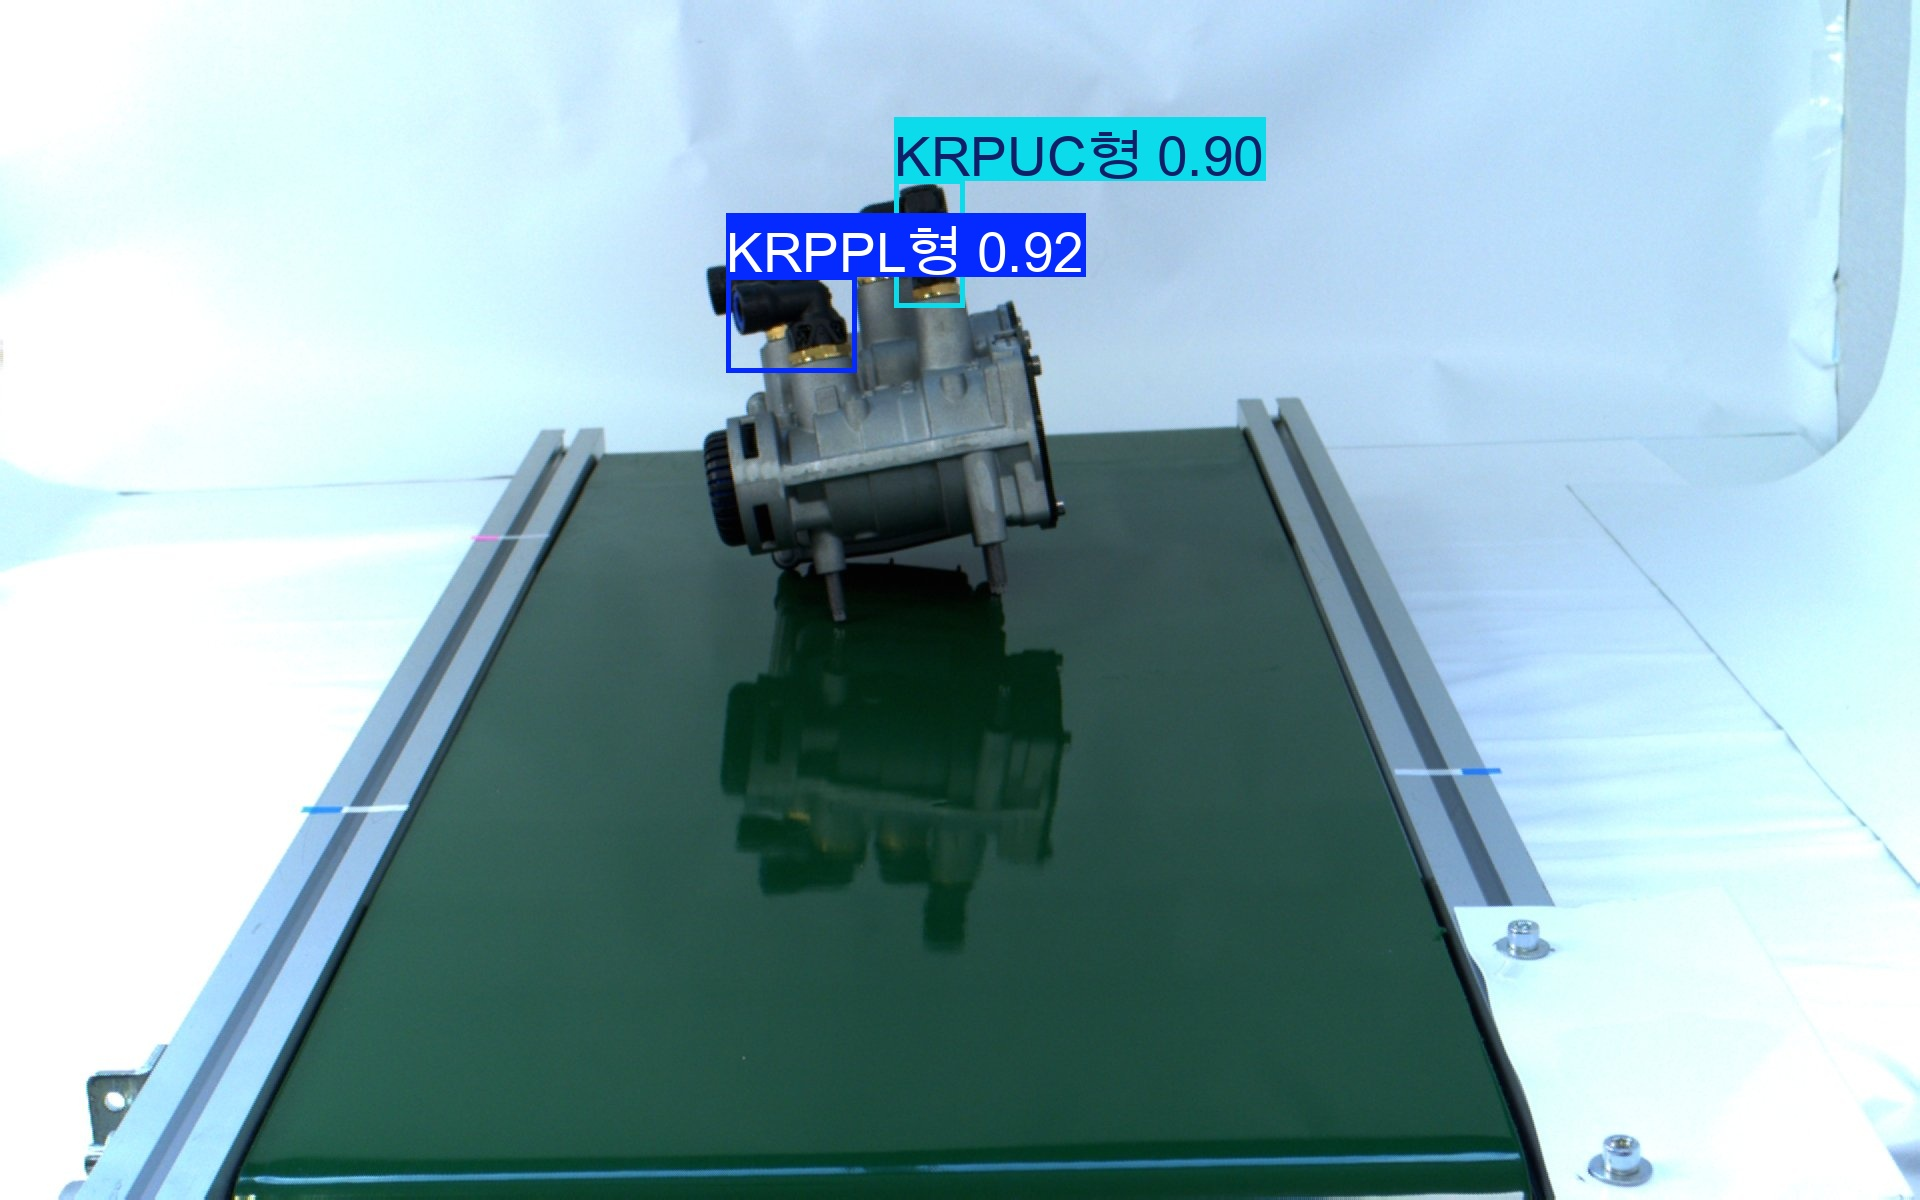

In [5]:
# 학습·검증 이미지에서 샘플 추론
sample_images = sorted((YOLO_DIR / "images" / "train").glob("*.jpg"))[:3]
sample_images += sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:2]

for img_path in sample_images:
    preds = best_model.predict(source=str(img_path), conf=CONF_THRESH, save=True, name=f"{EXPERIMENT}_predict")
    out_dir = Path(preds[0].save_dir)
    pred_img = out_dir / img_path.name
    print(f"\n[{img_path.parent.name}] {img_path.name}")
    for box in preds[0].boxes:
        cls_name = best_model.names[int(box.cls)]
        print(f"  - {cls_name}: conf={float(box.conf):.3f}")
    display(IPImage(filename=str(pred_img), width=600))

## 5. 검증셋 전체 추론 → 영상 출력

검증셋(val) **84장** 이미지를 순서대로 추론하고, 탐지 결과를 하나의 MP4 영상으로 저장합니다.
노트북에서는 용량 절감을 위해 GIF 미리보기도 함께 표시합니다.

검증 이미지 추론 시작: 84장
  [ 1/84] Module_001_A_CV_45_0029.jpg — 탐지 2건
  [10/84] Module_001_A_CV_45_0038.jpg — 탐지 2건
  [20/84] Module_001_A_CV_45_0048.jpg — 탐지 5건
  [30/84] Module_001_A_CV_45_0058.jpg — 탐지 5건
  [40/84] Module_001_A_CV_45_0068.jpg — 탐지 5건
  [50/84] Module_001_A_CV_45_0120.jpg — 탐지 4건
  [60/84] Module_001_A_CV_45_0130.jpg — 탐지 5건
  [70/84] Module_001_A_CV_45_0140.jpg — 탐지 6건
  [80/84] Module_001_A_CV_45_0150.jpg — 탐지 6건
  [84/84] Module_001_A_CV_45_0154.jpg — 탐지 5건

영상 저장: /content/runs/detect/yolo11_air_fitting_val_video/val_inference.mp4
GIF 미리보기: /content/runs/detect/yolo11_air_fitting_val_video/val_inference.preview.gif


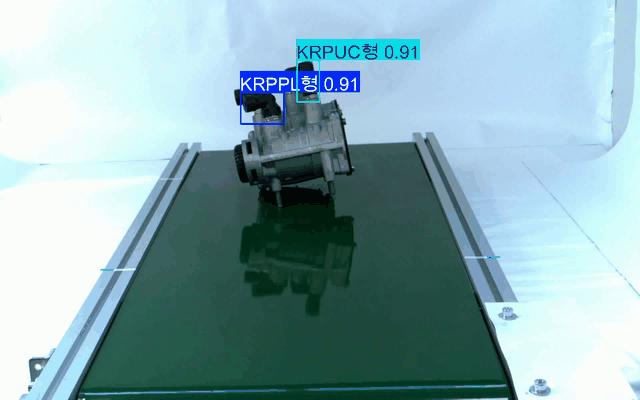

In [6]:
import cv2
from io import BytesIO
from IPython.display import Image as IPImage, display
from PIL import Image as PILImage

VAL_DIR = YOLO_DIR / "images" / "val"
val_images = sorted(VAL_DIR.glob("*.jpg"))
if not val_images:
    raise FileNotFoundError(f"검증 이미지가 없습니다: {VAL_DIR}")

VIDEO_OUT_DIR = ROOT / "runs" / "detect" / f"{EXPERIMENT}_val_video"
VIDEO_OUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_PATH = VIDEO_OUT_DIR / "val_inference.mp4"
GIF_PATH = VIDEO_PATH.with_suffix(".preview.gif")

FPS = 4  # 84장 × 4fps ≈ 21초
frames_bgr: list = []

print(f"검증 이미지 추론 시작: {len(val_images)}장")
for i, img_path in enumerate(val_images):
    results = best_model.predict(
        source=str(img_path),
        conf=CONF_THRESH,
        device=DEVICE,
        verbose=False,
    )
    frames_bgr.append(results[0].plot())
    if (i + 1) % 10 == 0 or i == 0 or i == len(val_images) - 1:
        n_det = len(results[0].boxes)
        print(f"  [{i + 1:>2}/{len(val_images)}] {img_path.name} — 탐지 {n_det}건")

h, w = frames_bgr[0].shape[:2]
writer = cv2.VideoWriter(
    str(VIDEO_PATH),
    cv2.VideoWriter_fourcc(*"mp4v"),
    FPS,
    (w, h),
)
for frame in frames_bgr:
    writer.write(frame)
writer.release()


def make_gif_preview(
    video_path: Path,
    gif_path: Path,
    every_n: int = 3,
    max_frames: int = 28,
    width: int = 640,
) -> Path:
    cap = cv2.VideoCapture(str(video_path))
    frames: list[PILImage.Image] = []
    idx = 0
    while len(frames) < max_frames:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % every_n == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil = PILImage.fromarray(rgb)
            if pil.width > width:
                ratio = width / pil.width
                pil = pil.resize((width, int(pil.height * ratio)), PILImage.LANCZOS)
            frames.append(pil)
        idx += 1
    cap.release()
    if not frames:
        raise RuntimeError(f"GIF 생성 실패: {video_path}")
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=150,
        loop=0,
    )
    return gif_path


make_gif_preview(VIDEO_PATH, GIF_PATH)
print(f"\n영상 저장: {VIDEO_PATH.resolve()}")
print(f"GIF 미리보기: {GIF_PATH.resolve()}")
display(IPImage(filename=str(GIF_PATH), width=700))

## 6. CLI 참고

```bash
# 학습
yolo detect train model=yolo11s.pt data=air_fitting_yolo/air_fitting.yaml epochs=100 imgsz=640 batch=8 device=0 name=yolo11_air_fitting

# 추론
yolo predict model=runs/detect/yolo11_air_fitting/weights/best.pt source=air_fitting_yolo/images/val conf=0.25 save=True
```

### 참고
- AI Hub 전체 데이터(22만+장)에서는 더 많은 `Annotation_part_type` 클래스가 등장합니다.
- 체결 상태(완전/부분/미체결/오류) 분류는 Swin Transformer 등 별도 모델이 권장됩니다.
- 본 예제는 **에어피팅 종류 검출** (YOLOv11) 에 초점을 맞춥니다.